<a href="https://colab.research.google.com/github/clarkti5/introduction-to-statistics/blob/main/2_3_Case_study_malaria_vaccine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Case study: malaria vaccine

---

#### Summary videos

- [Using randomization to analyze a gender discrimination case study](https://youtu.be/2pHhjx9hyM4?si=OCZymI0Euvc9O_b5) (5 minutes)


#### Walkthrough videos

- [Case study: malaria vaccine](https://drive.google.com/file/d/136nUJnk2yeLHsM7U__18xQzbCWGSC7sw/view?usp=drive_link) (13 minutes)

---

Below is a table from page 73 of the textbook summarizing the results of an experiment attempting to determine the efficacy of a malaria vaccine.

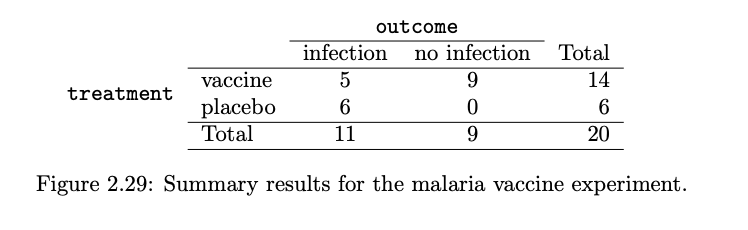

### Exercise

* How many patients were in the the experiment total?
* How many patients recieved a vaccine?
* How many patients recieved a placebo?
* What proportion of the patients that recieved a vaccine ended up with an infection?
* What proportion of the patients that recieved a placebo ended up with an infection?
* Does the table suggest that the vaccine was effective in preventing infection?

We note that the treatment group had an infection rate of about 35.7%, while the placebo group had an infection rate of 100%. So, there is a difference of about 64.3% in the infection rates between these groups.

To investigate if these results are simply due to chance, we propose the following hypotheses.

* $H_0$ **Independence Model (Null Hypothesis)**. The variables `treatement` and `outcome` are independent and the observed difference in infection rates (64.3%) is due to random chance.
* $H_A$ **Alternative Model (Alternative Hypothesis)**. The variables `treatment` and `outcome` are *not* independent and the difference in infection rates was affected by the vaccine.

Assuming $H_0$ (the *null hypothesis*), we can run some randomized simulations to see whether the observed difference in infection rates seems unusual or not.

First, we create a list of possible outcomes, namely `infection` and `no infection`. We can then tell Python to select an outcome randomly!

In [ ]:
import numpy as np

outcomes = np.array(['infection', 'no infection'])
print(np.random.choice(outcomes))

no infection


Now, we randomly deal 14 outcomes into a `vaccine` group, with `infection` occuring 55% of the time and `no infection` occuring 45% of the time. This is to simulate having 11 infected patients and 9 not infected patients out of 20 total patients, as was the case in the study.

In [ ]:
vaccine = np.random.choice(outcomes, size = 14, replace = True, p = [0.55, 0.45])

unique, counts = np.unique(vaccine, return_counts = True)
print(np.asarray((unique, counts)).T)

[['infection' '9']
 ['no infection' '5']]


We can then do the same for the placebo group and add up the total infected and not infected in each group.

In [ ]:
vaccine_infected = (vaccine == 'infection').sum()
vaccine_not_infected = (vaccine == 'no infection').sum()

placebo = np.random.choice(outcomes, size = 6, replace = True, p = [0.55, 0.45])
placebo_infected = (placebo == 'infection').sum()
placebo_not_infected = (placebo == 'no infection').sum()

print('Vaccine infected:', vaccine_infected)
print('Vaccine not infected:', vaccine_not_infected)
print('Placebo infected:', placebo_infected)
print('Placebo not infected:', placebo_not_infected)

Vaccine infected: 9
Vaccine not infected: 5
Placebo infected: 5
Placebo not infected: 1


Dividing `vaccine_infected` by 14 gives us the infection rate for the vaccine group.

In [ ]:
vaccine_infection_rate = vaccine_infected / 14

print(vaccine_infection_rate)

0.6428571428571429


Similarly, dividing `placebo_infected` by 6 gives us the infection rate for the placebo group.

In [ ]:
placebo_infection_rate = placebo_infected / 6

print(placebo_infection_rate)

0.8333333333333334


Finally, subtracting the infection rates gives us the difference in infection rates.

In [ ]:
infection_rate_difference = placebo_infection_rate - vaccine_infection_rate

print(infection_rate_difference)

0.19047619047619047


We can now run this simulation 1000 times!

In [ ]:
simulated_infection_rate_differences = []

for i in range(1000):
  vaccine = np.random.choice(outcomes, size = 14, replace = True, p = [0.55, 0.45])
  placebo = np.random.choice(outcomes, size = 6, replace = True, p = [0.55, 0.45])
  vaccine_infected = (vaccine == 'infection').sum()
  vaccine_not_infected = (vaccine == 'no infection').sum()

  placebo_infected = (placebo == 'infection').sum()
  placebo_not_infected = (placebo == 'no infection').sum()

  vaccine_infection_rate = vaccine_infected / 14
  placebo_infection_rate = placebo_infected / 6

  infection_rate_difference = placebo_infection_rate - vaccine_infection_rate

  simulated_infection_rate_differences.append(infection_rate_difference)

The code below will make a histogram visualizing the distribution of the simulated infection rate differences.

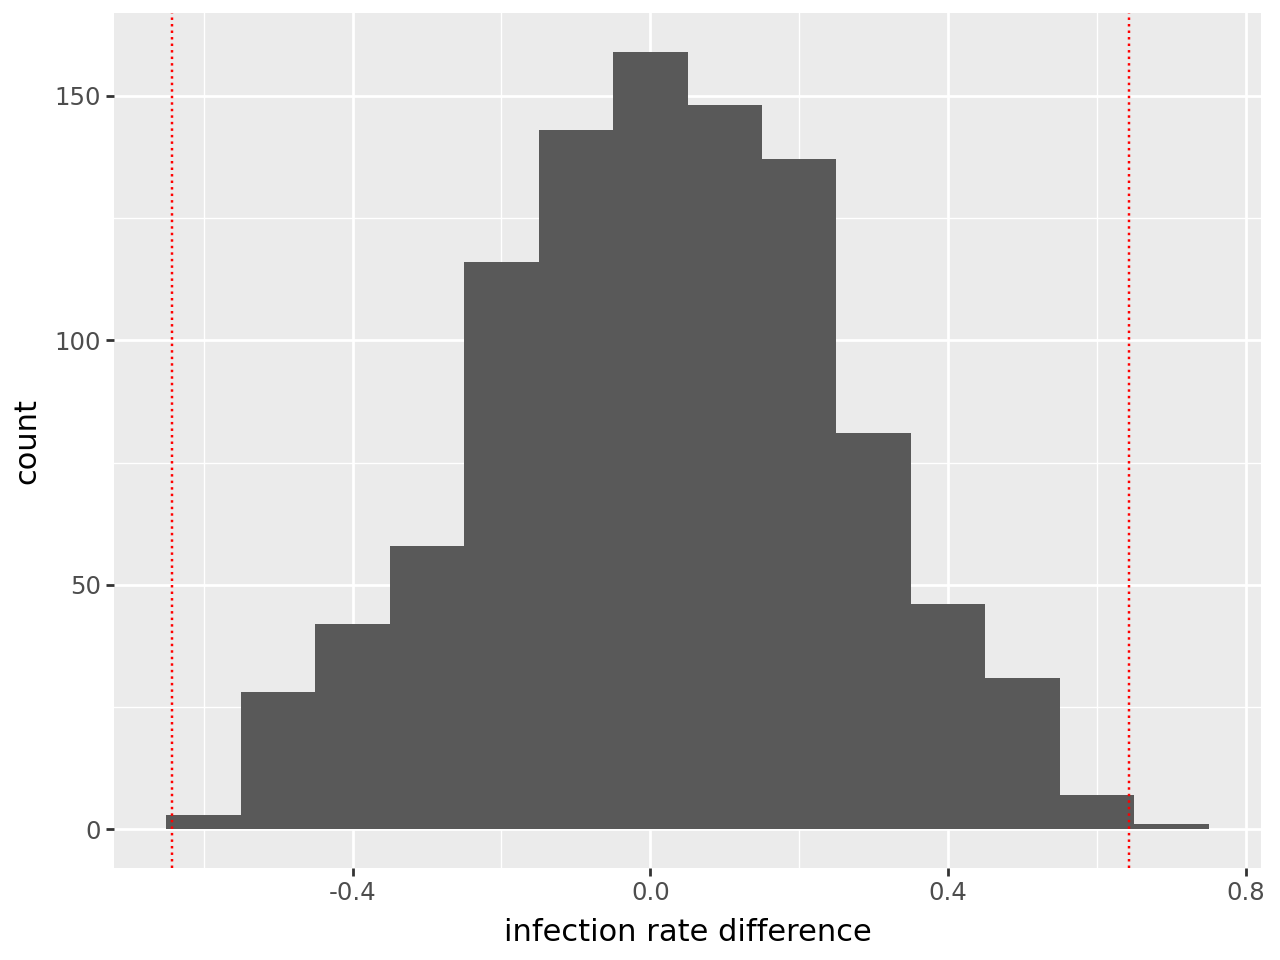

In [ ]:
import pandas as pd
from plotnine import *

(
  ggplot(pd.DataFrame(simulated_infection_rate_differences, columns = ['infection rate difference'])) +
  aes(x = 'infection rate difference') +
  geom_histogram(binwidth = 0.1) +
  geom_vline(xintercept=0.643, colour="red", linetype="dotted") +
  geom_vline(xintercept=-0.643, colour="red", linetype="dotted")
)

### Questions

* Recall, our experiment observed a difference of infection rates of 64.3%. If the infection rates were determined randomly (as in our simulation), is 64.3% a common or uncommon difference in infection rates?
* Given this information, are you inclined to reject $H_0$ or not? In other words, based on the randomized simulation, are you convinced that $H_0$ is not likely, and reject it in favor of the alternative? Or do you think there is not enough evidence to reject $H_0$?

---

This notebook was written by Timothy L. Clark, derivative of [OpenIntro Statistics by Diez, Çetinkaya-Rundel, and Barr](https://www.openintro.org/book/os/), released under [Creative Commons BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0/deed.en) license.